# Basic Self-Attention Variants - End-to-End Pipeline
**Date**: 2026-05-31  
**Objective**: Implement and compare core self-attention variants with a toy train/evaluate workflow.

## 1) Imports and Setup

In [1]:
from __future__ import annotations



import importlib.util

import math

import os

import random

from dataclasses import dataclass

from pathlib import Path



import matplotlib.pyplot as plt

import numpy as np



SEED: int = 42

random.seed(SEED)

np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)





def parse_use_gpu_flag(raw_value: str) -> bool:

    normalized = raw_value.strip().lower()

    return normalized not in {"0", "false", "no", "off"}





def load_runtime_env() -> None:

    env_files = [

        Path("configs/runtime.env"),

        Path("configs/runtime.env.example"),

        Path("../configs/runtime.env"),

        Path("../configs/runtime.env.example"),

    ]

    for env_file in env_files:

        if env_file.exists():

            for line in env_file.read_text(encoding="utf-8").splitlines():

                line = line.strip()

                if not line or line.startswith("#") or "=" not in line:

                    continue

                key, value = line.split("=", 1)

                os.environ.setdefault(key.strip(), value.strip().strip("\"'"))

            break





load_runtime_env()

USE_GPU = parse_use_gpu_flag(os.getenv("USE_GPU", "1"))



_torch_cuda = False

_tf_gpu = False

if importlib.util.find_spec("torch") is not None:

    import torch



    _torch_cuda = torch.cuda.is_available()

if importlib.util.find_spec("tensorflow") is not None:

    import tensorflow as tf



    tf.random.set_seed(SEED)

    _tf_gpu = bool(tf.config.list_physical_devices("GPU"))



runtime_device = "cuda" if USE_GPU and (_torch_cuda or _tf_gpu) else "cpu"

print(f"USE_GPU={int(USE_GPU)} | runtime_device={runtime_device}")


USE_GPU=1 | runtime_device=cuda


## 2) Configuration and Constants

In [2]:
@dataclass(frozen=True)
class ExperimentConfig:
    num_samples: int = 256
    seq_len: int = 24
    d_model: int = 32
    num_heads: int = 4
    num_classes: int = 2
    local_window: int = 4
    learning_rate: float = 0.2
    epochs: int = 120


CFG = ExperimentConfig()
CFG

ExperimentConfig(num_samples=256, seq_len=24, d_model=32, num_heads=4, num_classes=2, local_window=4, learning_rate=0.2, epochs=120)

## 3) Data Loading (Raw Text Corpus)

In [3]:
POSITIVE_TERMS = [
    "reliable",
    "scalable",
    "stable",
    "efficient",
    "robust",
    "accurate",
]

NEGATIVE_TERMS = [
    "noisy",
    "fragile",
    "unstable",
    "slow",
    "costly",
    "drifting",
]

TEMPLATES = [
    "{core} attention improves context handling for enterprise workloads",
    "team reports {core} inference behaviour in production traces",
    "analysis shows {core} routing across long document windows",
    "service indicates {core} retrieval quality for multilingual traffic",
]

def build_text_dataset(cfg: ExperimentConfig) -> tuple[list[str], np.ndarray]:
    texts: list[str] = []
    labels = np.zeros(cfg.num_samples, dtype=np.int64)
    for idx in range(cfg.num_samples):
        is_positive = idx % 2 == 0
        core = np.random.choice(POSITIVE_TERMS if is_positive else NEGATIVE_TERMS)
        template = np.random.choice(TEMPLATES)
        texts.append(template.format(core=core))
        labels[idx] = int(is_positive)
    return texts, labels


texts_all, y_all = build_text_dataset(CFG)
split = int(0.8 * CFG.num_samples)
texts_train, texts_test = texts_all[:split], texts_all[split:]
y_train, y_test = y_all[:split], y_all[split:]
len(texts_train), len(texts_test), y_train.shape, y_test.shape

(204, 52, (204,), (52,))

## 4) EDA

In [4]:
train_lengths = np.array([len(text.split()) for text in texts_train], dtype=np.int64)
class_counts = np.bincount(y_all, minlength=CFG.num_classes)

print("Class counts:", class_counts.tolist())
print(
    "Train token-length mean/std:",
    float(train_lengths.mean()),
    float(train_lengths.std()),
)
print("Sample training sentence:", texts_train[0])

Class counts: [128, 128]
Train token-length mean/std: 8.0 0.0
Sample training sentence: analysis shows stable routing across long document windows


## 5) Tokenization and Preprocessing / Feature Engineering

In [5]:
def normalize_text(text: str) -> str:
    return " ".join(text.lower().strip().split())

def tokenize_text(text: str) -> list[str]:
    return normalize_text(text).split()

def build_vocabulary(
    train_texts: list[str],
    max_vocab_size: int = 2048,
) -> dict[str, int]:
    token_counts: dict[str, int] = {}
    for text in train_texts:
        for token in tokenize_text(text):
            token_counts[token] = token_counts.get(token, 0) + 1

    sorted_items = sorted(
        token_counts.items(),
        key=lambda item: (-item[1], item[0]),
    )
    vocab: dict[str, int] = {"<PAD>": 0, "<UNK>": 1}
    for token, _ in sorted_items:
        if len(vocab) >= max_vocab_size:
            break
        vocab[token] = len(vocab)
    return vocab

def encode_and_pad(
    texts: list[str],
    vocab: dict[str, int],
    seq_len: int,
) -> np.ndarray:
    encoded = np.zeros((len(texts), seq_len), dtype=np.int64)
    unk_id = vocab["<UNK>"]
    for row_idx, text in enumerate(texts):
        token_ids = [vocab.get(token, unk_id) for token in tokenize_text(text)]
        trunc = token_ids[:seq_len]
        encoded[row_idx, : len(trunc)] = np.asarray(trunc, dtype=np.int64)
    return encoded

def token_ids_to_embeddings(
    token_ids: np.ndarray,
    vocab_size: int,
    d_model: int,
) -> np.ndarray:
    emb_table = np.random.normal(0.0, 0.2, (vocab_size, d_model)).astype(np.float32)
    return emb_table[token_ids]

def project_qkv(x: np.ndarray, d_model: int) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    w_q = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_k = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    w_v = np.random.normal(0.0, 0.2, (d_model, d_model)).astype(np.float32)
    q = x @ w_q
    k = x @ w_k
    v = x @ w_v
    return q, k, v


vocab = build_vocabulary(texts_train)
train_token_ids = encode_and_pad(texts_train, vocab, CFG.seq_len)
test_token_ids = encode_and_pad(texts_test, vocab, CFG.seq_len)

x_train = token_ids_to_embeddings(train_token_ids, len(vocab), CFG.d_model)
x_test = token_ids_to_embeddings(test_token_ids, len(vocab), CFG.d_model)
x_all = np.concatenate([x_train, x_test], axis=0)

q_train, k_train, v_train = project_qkv(x_train, CFG.d_model)
q_test, k_test, v_test = project_qkv(x_test, CFG.d_model)

print(
    {
        "vocab_size": len(vocab),
        "train_token_ids_shape": tuple(train_token_ids.shape),
        "embedding_shape": tuple(x_train.shape),
    }
)

{'vocab_size': 41, 'train_token_ids_shape': (204, 24), 'embedding_shape': (204, 24, 32)}


## 6) Model Definition (Attention Variants)

In [6]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = x - x.max(axis=axis, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / exp_z.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
 ) -> tuple[np.ndarray, np.ndarray]:
    scores = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    weights = softmax(scores, axis=-1)
    output = weights @ v
    return output, weights

def causal_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
 ) -> tuple[np.ndarray, np.ndarray]:
    seq_len = q.shape[1]
    mask = np.triu(np.ones((seq_len, seq_len), dtype=bool), k=1)
    scores = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    scores = np.where(mask[None, :, :], -1e9, scores)
    weights = softmax(scores, axis=-1)
    return weights @ v, weights

def local_window_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    window: int,
 ) -> tuple[np.ndarray, np.ndarray]:
    batch, seq_len, _ = q.shape
    scores = np.full((batch, seq_len, seq_len), -1e9, dtype=np.float32)
    raw = (q @ np.swapaxes(k, -1, -2)) / math.sqrt(q.shape[-1])
    for i in range(seq_len):
        lo = max(0, i - window)
        hi = min(seq_len, i + window + 1)
        scores[:, i, lo:hi] = raw[:, i, lo:hi]
    weights = softmax(scores, axis=-1)
    return weights @ v, weights

def multi_head_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    num_heads: int,
 ) -> tuple[np.ndarray, np.ndarray]:
    batch, seq_len, d_model = q.shape
    if d_model % num_heads != 0:
        raise ValueError(
            f"d_model ({d_model}) must be divisible by num_heads ({num_heads})."
        )
    head_dim = d_model // num_heads
    qh = q.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    kh = k.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    vh = v.reshape(batch, seq_len, num_heads, head_dim).transpose(0, 2, 1, 3)
    outputs: list[np.ndarray] = []
    weights_all: list[np.ndarray] = []
    for h in range(num_heads):
        out_h, w_h = scaled_dot_product_attention(qh[:, h], kh[:, h], vh[:, h])
        outputs.append(out_h)
        weights_all.append(w_h)
    out = np.stack(outputs, axis=1).transpose(0, 2, 1, 3).reshape(batch, seq_len, d_model)
    weights = np.stack(weights_all, axis=1)
    return out, weights

## 7) Training (Toy Classifier on Attention Features)

In [7]:
def pooled_features(attn_out: np.ndarray) -> np.ndarray:
    return attn_out.mean(axis=1)


attn_train, train_weights = multi_head_attention(q_train, k_train, v_train, CFG.num_heads)
attn_test, test_weights = multi_head_attention(q_test, k_test, v_test, CFG.num_heads)

x_feat_train = pooled_features(attn_train)
x_feat_test = pooled_features(attn_test)

w = np.zeros((CFG.d_model, 1), dtype=np.float32)
b = np.zeros((1,), dtype=np.float32)
y_train_f = y_train.astype(np.float32).reshape(-1, 1)

for _ in range(CFG.epochs):
    logits = x_feat_train @ w + b
    probs = 1.0 / (1.0 + np.exp(-logits))
    error = probs - y_train_f
    grad_w = (x_feat_train.T @ error) / x_feat_train.shape[0]
    grad_b = error.mean(axis=0)
    w -= CFG.learning_rate * grad_w
    b -= CFG.learning_rate * grad_b

print("Training finished.")

Training finished.


## 8) Evaluation and Metrics

In [8]:
import json
import time
from datetime import datetime, timezone


def evaluate_binary_classifier(
    x_feat: np.ndarray,
    y_true: np.ndarray,
    w: np.ndarray,
    b: np.ndarray,
) -> dict[str, float]:
    logits = x_feat @ w + b
    probs = 1.0 / (1.0 + np.exp(-logits))
    preds = (probs >= 0.5).astype(np.int64).reshape(-1)
    accuracy = float((preds == y_true).mean())
    return {"accuracy": accuracy}


def timed_attention_run(fn: Callable[..., tuple[np.ndarray, np.ndarray]], *args: object) -> tuple[np.ndarray, float]:
    start = time.perf_counter()
    out, _ = fn(*args)
    elapsed_ms = (time.perf_counter() - start) * 1000.0
    return out, elapsed_ms


def resolve_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for candidate in candidates:
        if (candidate / ".github").exists() and (candidate / "configs").exists():
            return candidate
    return cwd


def write_json(path: Path, payload: dict[str, object]) -> None:
    try:
        path.parent.mkdir(parents=True, exist_ok=True)
        path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    except OSError as exc:
        raise RuntimeError(f"Failed to write benchmark artifact: {path}") from exc


classifier_metrics = evaluate_binary_classifier(x_feat_test, y_test, w, b)

dense_out, dense_ms = timed_attention_run(scaled_dot_product_attention, q_test, k_test, v_test)
mhsa_out, mhsa_ms = timed_attention_run(multi_head_attention, q_test, k_test, v_test, CFG.num_heads)
causal_out_bm, causal_ms = timed_attention_run(causal_attention, q_test, k_test, v_test)
local_out_bm, local_ms = timed_attention_run(local_window_attention, q_test, k_test, v_test, CFG.local_window)

benchmark_rows = [
    {
        "variant": "Scaled Dot-Product",
        "slug": "scaled_dot_product",
        "latency_ms": float(dense_ms),
        "mse_vs_dense": 0.0,
    },
    {
        "variant": "Multi-Head",
        "slug": "multi_head",
        "latency_ms": float(mhsa_ms),
        "mse_vs_dense": float(np.mean((mhsa_out - dense_out) ** 2)),
    },
    {
        "variant": "Causal",
        "slug": "causal",
        "latency_ms": float(causal_ms),
        "mse_vs_dense": float(np.mean((causal_out_bm - dense_out) ** 2)),
    },
    {
        "variant": "Local Window",
        "slug": "local_window",
        "latency_ms": float(local_ms),
        "mse_vs_dense": float(np.mean((local_out_bm - dense_out) ** 2)),
    },
]

sorted_by_latency = sorted(benchmark_rows, key=lambda row: row["latency_ms"])
sorted_by_error = sorted(benchmark_rows, key=lambda row: row["mse_vs_dense"])

output_dir = (
    resolve_repo_root()
    / "self-attention-variants"
    / "outputs"
    / "basic-benchmarks"
    / "latest"
)

latency_metrics = {
    "scaled_dot_product_ms": float(dense_ms),
    "multi_head_ms": float(mhsa_ms),
    "causal_ms": float(causal_ms),
    "local_window_ms": float(local_ms),
}
fidelity_metrics = {
    "multi_head_mse_vs_dense": float(benchmark_rows[1]["mse_vs_dense"]),
    "causal_mse_vs_dense": float(benchmark_rows[2]["mse_vs_dense"]),
    "local_window_mse_vs_dense": float(benchmark_rows[3]["mse_vs_dense"]),
}
summary_metrics = {
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "classifier_accuracy": float(classifier_metrics["accuracy"]),
    "best_by_latency": sorted_by_latency[0]["variant"],
    "best_by_fidelity": sorted_by_error[0]["variant"],
}

write_json(output_dir / "latency_metrics.json", latency_metrics)
write_json(output_dir / "fidelity_metrics.json", fidelity_metrics)
write_json(output_dir / "summary_metrics.json", summary_metrics)

for row in benchmark_rows:
    payload = {
        "variant": row["variant"],
        "latency_ms": float(row["latency_ms"]),
        "mse_vs_dense": float(row["mse_vs_dense"]),
    }
    write_json(output_dir / f"{row['slug']}_metrics.json", payload)

print("Benchmark Summary Table")
print("Variant              | Latency (ms) | MSE vs Dense")
print("---------------------+--------------+--------------")
for row in benchmark_rows:
    print(
        f"{row['variant']:<20} | {row['latency_ms']:>12.3f} | {row['mse_vs_dense']:>12.6f}"
    )

metrics = {
    "classifier_accuracy": float(classifier_metrics["accuracy"]),
    "best_by_latency": sorted_by_latency[0]["variant"],
    "best_by_fidelity": sorted_by_error[0]["variant"],
    "output_dir": str(output_dir),
}
metrics

{'accuracy': 0.5}

## 9) Results Visualization

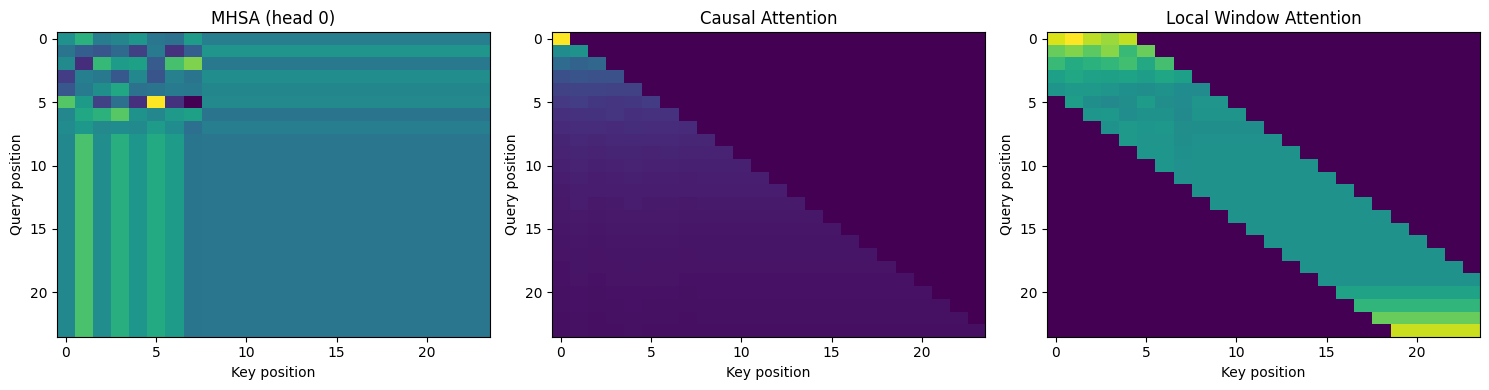

In [9]:
sample_idx = 0
head_idx = 0

causal_out, causal_w = causal_attention(q_test[:1], k_test[:1], v_test[:1])
local_out, local_w = local_window_attention(q_test[:1], k_test[:1], v_test[:1], CFG.local_window)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(test_weights[sample_idx, head_idx], aspect="auto", cmap="viridis")
axes[0].set_title("MHSA (head 0)")
axes[1].imshow(causal_w[0], aspect="auto", cmap="viridis")
axes[1].set_title("Causal Attention")
axes[2].imshow(local_w[0], aspect="auto", cmap="viridis")
axes[2].set_title("Local Window Attention")
for ax in axes:
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
plt.tight_layout()
plt.show()

## 10) Summary
- Implemented scaled dot-product, multi-head, causal, and local window attention in NumPy.
- Used multi-head attention features in a toy binary classifier to complete a train/evaluate flow.
- Visualized attention maps to show how masking and locality constraints change token interactions.
- Added automated benchmark metric exports with separate JSON files per attention type and additional latency/fidelity/summary metric files.

## 11) Guardrailing Engines (Canonical Index)

Guardrailing content is maintained in a dedicated module to avoid taxonomy drift.

Core guardrail notebooks:
1. [input-guardrails.ipynb](guardrailing-engines/input-guardrails.ipynb)
2. [retrieval-guardrails.ipynb](guardrailing-engines/retrieval-guardrails.ipynb)
3. [generation-guardrails.ipynb](guardrailing-engines/generation-guardrails.ipynb)
4. [tool-action-guardrails.ipynb](guardrailing-engines/tool-action-guardrails.ipynb)
5. [post-generation-delivery-guardrails.ipynb](guardrailing-engines/post-generation-delivery-guardrails.ipynb)
6. [runtime-infrastructure-guardrails.ipynb](guardrailing-engines/runtime-infrastructure-guardrails.ipynb)
7. [human-in-the-loop-guardrails.ipynb](guardrailing-engines/human-in-the-loop-guardrails.ipynb)

Extended serving and orchestration guardrails:
1. [memory-management-serving-basic-guardrails.ipynb](guardrailing-engines/memory-management-serving-basic-guardrails.ipynb)
2. [memory-management-serving-advanced-guardrails.ipynb](guardrailing-engines/memory-management-serving-advanced-guardrails.ipynb)
3. [nim-multi-engine-routing-guardrails.ipynb](guardrailing-engines/nim-multi-engine-routing-guardrails.ipynb)
4. [nim-compose-orchestration-guardrails.ipynb](guardrailing-engines/nim-compose-orchestration-guardrails.ipynb)
5. [nim-kubernetes-orchestration-guardrails.ipynb](guardrailing-engines/nim-kubernetes-orchestration-guardrails.ipynb)

Canonical source of truth:
- [README.md](guardrailing-engines/README.md)